# ESS8 Belief Data — Exploration

Processed from ESS Round 8 (2016) following Broere et al. (2022).  
20 belief dimensions, coded higher = right-wing/conservative, normalised to [0, 1].

## Imports

In [22]:
import sys
sys.path.insert(0, "../src")

import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from belief_network import BeliefNetwork
import networkx as nx

sns.set_theme(style="whitegrid")
%matplotlib inline

## Load data

In [2]:
DATA_PATH = "../input/data/ESS8e02_3_self_processed/ess8_cca_initial_beliefs.csv"

df = pd.read_csv(DATA_PATH)

BELIEF_DIMS = [
    "left_right_identification", "gender_inequality", "anti_lgbt",
    "euroscepticism", "anti_immigration", "anti_egalitarianism",
    "benefits_harm_economy", "benefits_harm_society", "welfare_chauvinism",
    "anti_economic_interventionism", "anti_social_benefits_low_income",
    "anti_social_benefits_parents", "educational_spending",
    "anti_basic_income", "anti_climate_change_taxes",
    "anti_climate_change_renewables", "anti_climate_ban_appliances",
    "climate_skepticism", "authoritarianism", "anti_libertarianism",
]

print(f"Respondents: {len(df):,}")
print(f"Countries:   {sorted(df['cntry'].unique())}")
print(f"Belief dims: {len(BELIEF_DIMS)}")
df.head()

Respondents: 37,118
Countries:   ['AT', 'BE', 'CH', 'CZ', 'DE', 'EE', 'ES', 'FI', 'FR', 'GB', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'NL', 'NO', 'PL', 'PT', 'RU', 'SE', 'SI']
Belief dims: 20


,ess_row_id,idno,cntry,country_name,ess_unique_id,agea,gndr,eisced,education_3cat,hinctnta,...,educational_spending,anti_basic_income,anti_climate_change_taxes,anti_climate_change_renewables,anti_climate_ban_appliances,climate_skepticism,authoritarianism,anti_libertarianism,n_belief_missing,n_belief_available
0,1,1,AT,Austria,AT_1,34.0,2.0,7.0,3.0,NaN,...,NaN,0.000000,0.00,0.00,0.25,0.25,0.20,0.28,1,19
1,2,2,AT,Austria,AT_2,52.0,1.0,4.0,2.0,5.0,...,0.666667,0.333333,0.00,0.25,0.25,0.25,0.24,0.44,0,20
2,3,4,AT,Austria,AT_4,68.0,2.0,3.0,2.0,2.0,...,0.333333,1.000000,0.75,0.25,0.25,0.25,0.72,0.56,0,20
3,4,6,AT,Austria,AT_6,54.0,1.0,3.0,2.0,4.0,...,0.666667,NaN,0.50,0.50,0.50,0.50,0.68,0.28,2,18
4,5,10,AT,Austria,AT_10,20.0,2.0,3.0,2.0,2.0,...,0.333333,0.333333,0.50,0.00,0.75,0.25,0.48,0.40,0,20


In [30]:
df[df.cntry == "GB"][BELIEF_DIMS].describe().T

,count,mean,std,min,25%,50%,75%,max
left_right_identification,1667.0,0.495441,0.190225,0.0,0.400000,0.500000,0.600000,1.000000
gender_inequality,1791.0,0.172669,0.219878,0.0,0.000000,0.000000,0.250000,1.000000
anti_lgbt,1776.0,0.239396,0.205245,0.0,0.083333,0.250000,0.333333,1.000000
euroscepticism,1712.0,0.584346,0.252539,0.0,0.500000,0.500000,0.800000,1.000000
anti_immigration,1751.0,0.422806,0.242017,0.0,0.333333,0.333333,0.611111,1.000000
anti_egalitarianism,1776.0,0.439048,0.185031,0.0,0.333333,0.416667,0.583333,1.000000
benefits_harm_economy,1757.0,0.540054,0.204602,0.0,0.375000,0.500000,0.750000,1.000000
benefits_harm_society,1780.0,0.444803,0.181844,0.0,0.250000,0.500000,0.500000,1.000000
welfare_chauvinism,1763.0,0.550340,0.212205,0.0,0.500000,0.500000,0.750000,1.000000
anti_economic_interventionism,1788.0,0.312826,0.146469,0.0,0.200000,0.300000,0.400000,0.833333


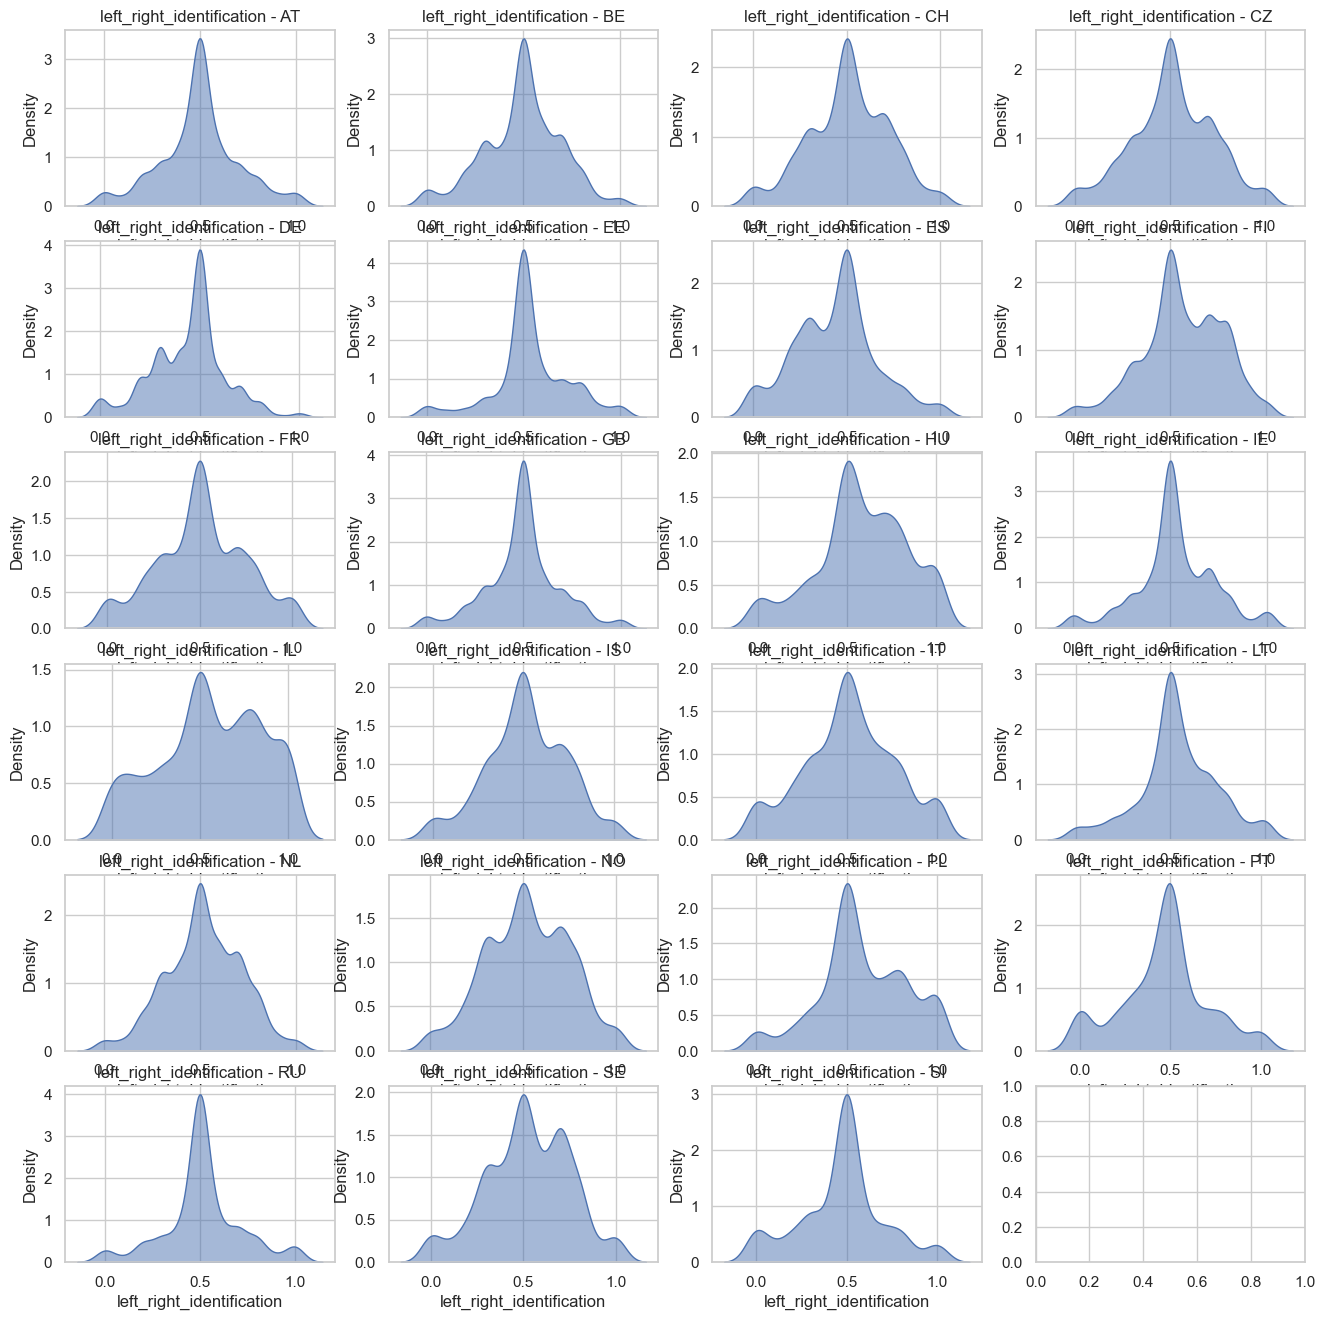

In [35]:
# Plot the distribution of beliefs for each dimension
# Start with left-right identification
fig, axes = plt.subplots(6, 4, figsize=(16, 16))
BELIEF = "left_right_identification"

i=0
j=0
for cntry in sorted(df.cntry.unique()):
    sns.kdeplot(
        data=df[df.cntry == cntry],
        x=BELIEF,
        ax=axes[i, j],
        label=cntry,
        fill=True,
        alpha=0.5,
    )

    axes[i, j].set_title(f"{BELIEF} - {cntry}")
    j += 1
    if j == 4:
        j = 0
        i += 1

## Belief network inference

We infer a weighted undirected network over the 20 belief dimensions using the MDL method of Peixoto (2025).

**Generative model**: multivariate Gaussian — respondents are i.i.d. samples from a Normal distribution whose precision matrix (inverse covariance) encodes the network edge weights. Edges that can be explained away by indirect paths are pruned by the MDL prior.

**Implementation**: `PseudoNormalBlockState` from graph-tool. This uses a pseudolikelihood approximation (belief propagation) together with a nested stochastic block model as the structural prior, which provides the MDL regularisation without requiring cross-validation.

**Data layout**: graph-tool expects an `(N, M)` array — rows are the N=20 nodes (belief dimensions), columns are the M respondents (independent samples).

**Missing values**: the state requires complete data. We use per-column mean imputation, which is conservative (pulls partial observations toward the centre) but retains all respondents.

In [7]:
bn = BeliefNetwork(BELIEF_DIMS)
bn.fit(df[df.cntry == "GB"])

iter  100 | DL = -5872.9 | edges = 101
Converged at iteration 181

Final description length : -5982.8
Inferred edges           : 95


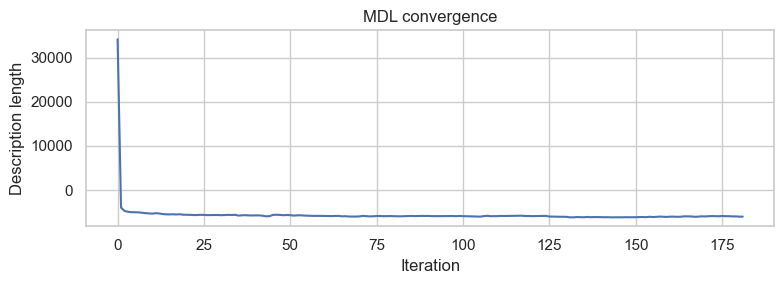

In [8]:
bn.plot_convergence()
plt.tight_layout()
plt.show()

In [4]:
bn.get_edge_list()

NameError: name 'bn' is not defined

In [12]:
bn.get_edge_list().describe()

,weight
count,95.000000
mean,-1.710699
std,2.355349
min,-9.901876
25%,-2.756743
50%,-1.446244
75%,-1.412953
max,5.976928


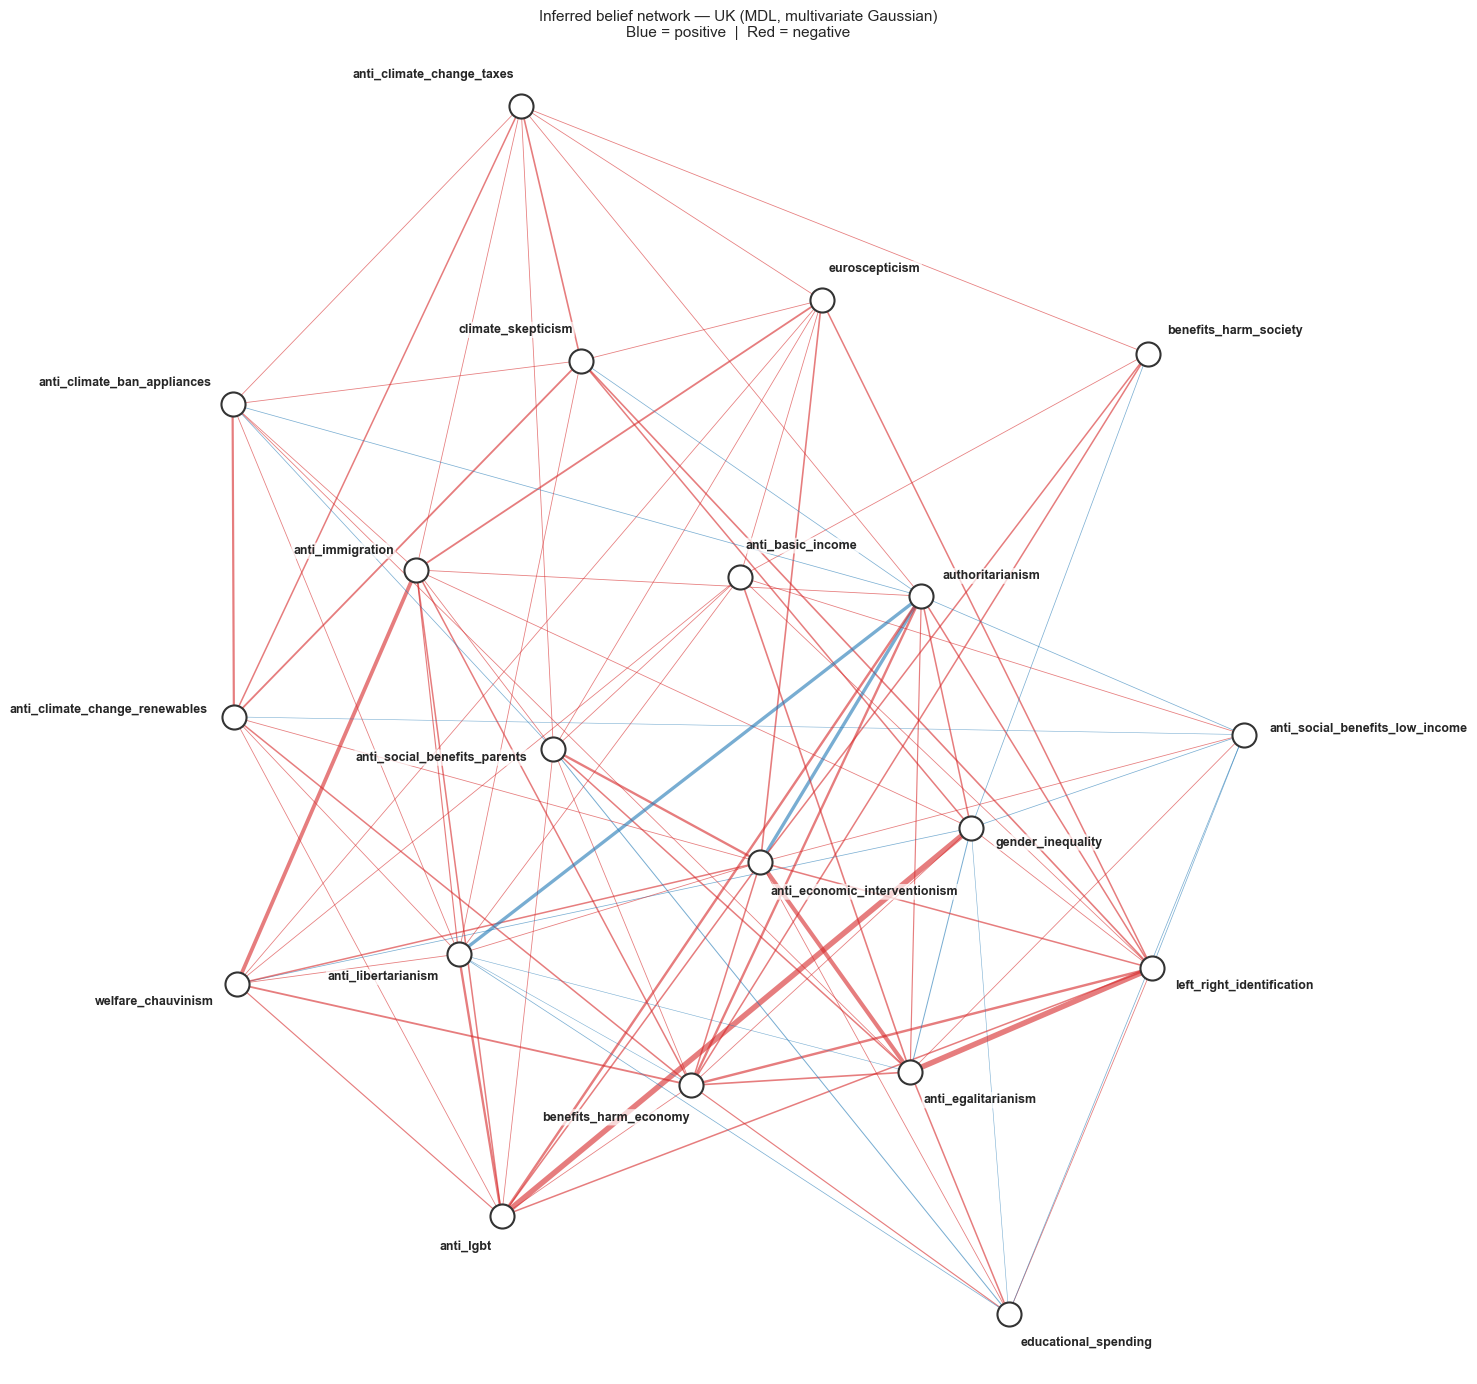

In [10]:
bn.plot_network(title="Inferred belief network — UK (MDL, multivariate Gaussian)\n"
                "Blue = positive  |  Red = negative")
plt.tight_layout()
plt.show()

In [11]:
bn.save('../output/networks/UK.graphml')

In [5]:
# Check network reconstruction changing the range of responses from [0, 1] to [-1, 1]
df_c = df[df.cntry == "GB"].copy()

# Transform only the belief columns from [0, 1] to [-1, 1]
for col in df_c.columns:
    if col in BELIEF_DIMS:
        df_c[col] = df_c[col] * 2 - 1

bn_rescaled = BeliefNetwork(BELIEF_DIMS)
bn_rescaled.fit(df_c, verbose=False)

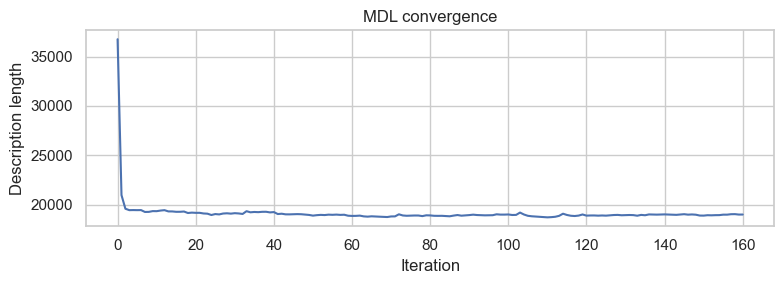

In [7]:
bn_rescaled.plot_convergence()
plt.tight_layout()
plt.show()

In [8]:
bn_rescaled.get_edge_list()

,source,target,weight
0,left_right_identification,anti_climate_change_renewables,-0.326138
1,left_right_identification,anti_lgbt,-0.657848
2,left_right_identification,euroscepticism,-0.800257
3,left_right_identification,climate_skepticism,-0.657848
4,left_right_identification,educational_spending,-0.326138
...,...,...,...
87,authoritarianism,benefits_harm_economy,-1.271725
88,anti_libertarianism,climate_skepticism,-0.326138
89,anti_libertarianism,welfare_chauvinism,-0.326138
90,anti_libertarianism,educational_spending,0.956001


In [10]:
bn_rescaled.get_edge_list().describe()

,weight
count,92.000000
mean,-0.441015
std,0.624935
min,-2.507166
25%,-0.657848
50%,-0.326138
75%,-0.326138
max,1.671836


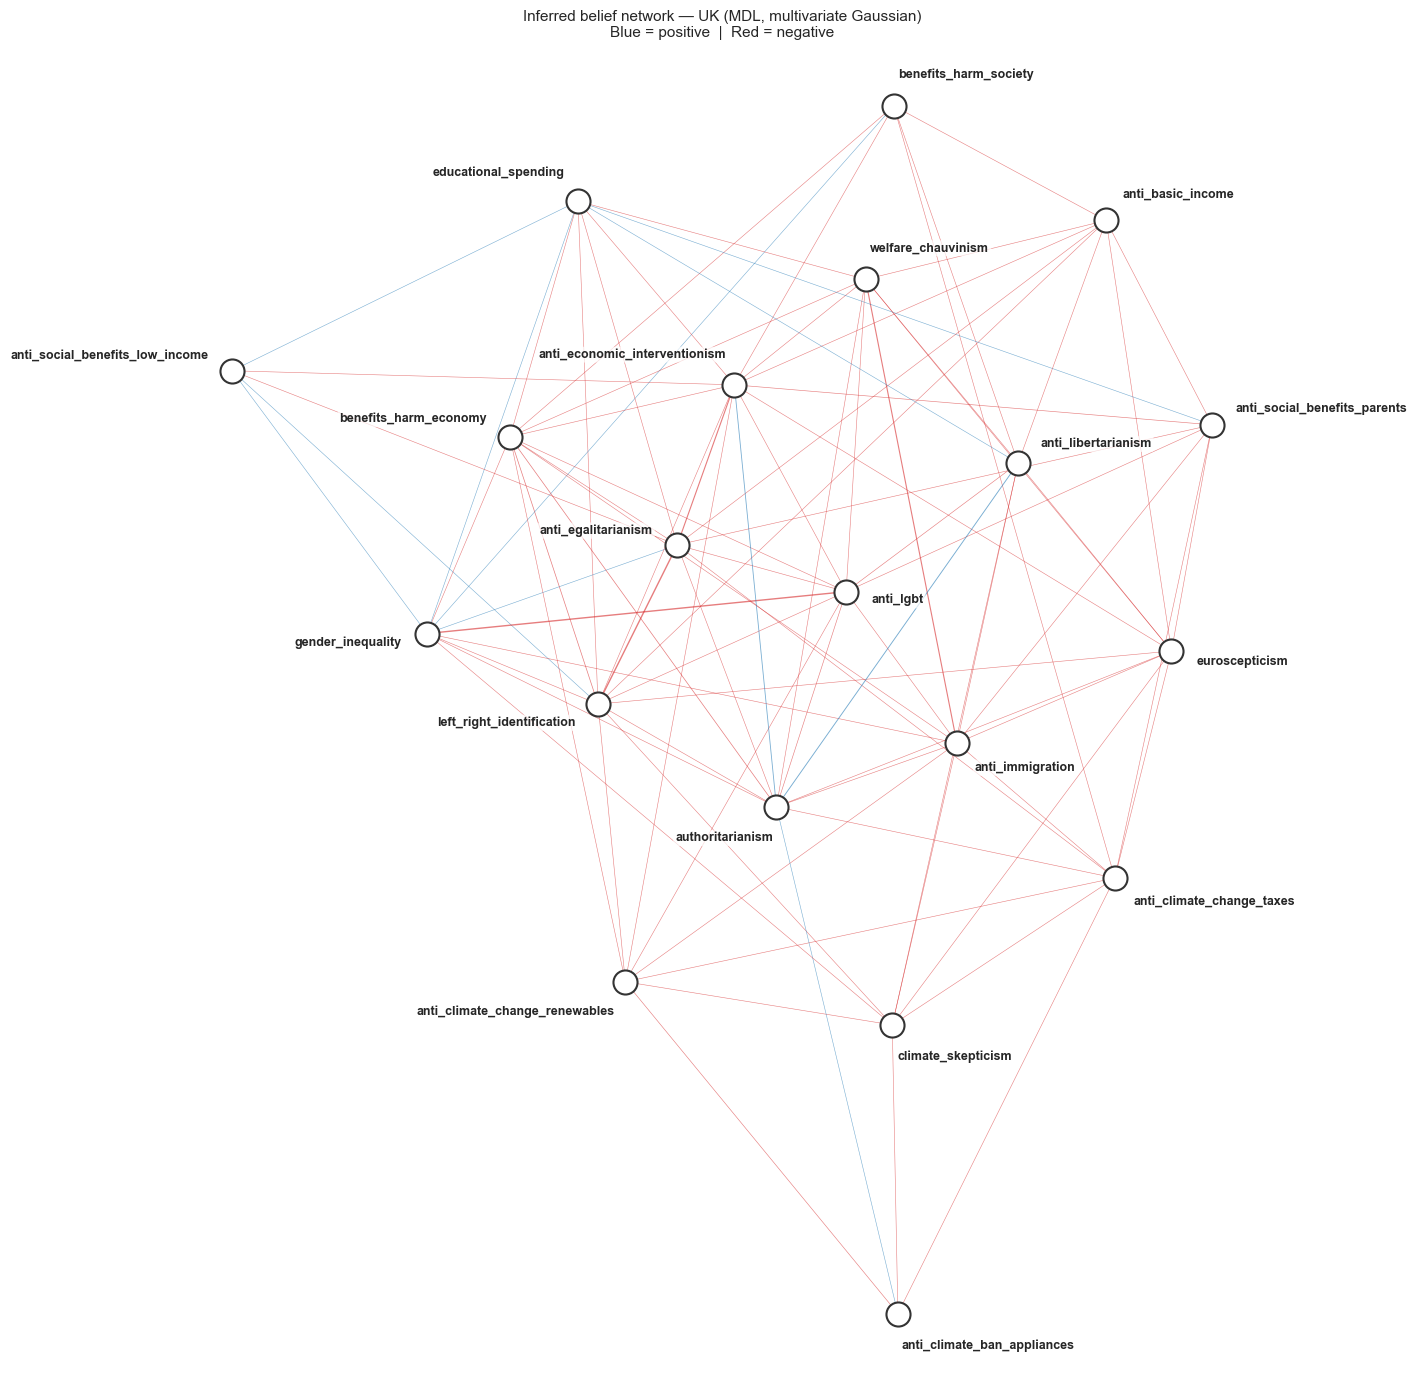

In [9]:
bn_rescaled.plot_network(title="Inferred belief network — UK (MDL, multivariate Gaussian)\n"
                "Blue = positive  |  Red = negative")
plt.tight_layout()
plt.show()

In [11]:
W = bn_rescaled.state.get_precision().todense()
D = np.sqrt(np.diag(W))
partial_corr = -W / np.outer(D, D)
np.fill_diagonal(partial_corr, 1.0)

In [14]:
# How many non-zero edges are there in the partial correlation matrix?
non_zero_edges = np.sum(np.abs(partial_corr) > 1e-5)
print(f"Number of non-zero edges in the partial correlation matrix: {non_zero_edges}")

Number of non-zero edges in the partial correlation matrix: 204


## Compare inferred edges vs partial correlations

The partial correlations from `get_precision()` are derived from the same inferred precision matrix, so the edge sets should match exactly. But we can also compare against partial correlations computed *directly* from the sample covariance (i.e., inverting the empirical covariance matrix without any MDL regularisation) to see which edges Peixoto's method prunes.

In [15]:
# Edges from Peixoto's inferred network
inferred_edges = set()
for e in bn_rescaled.graph.edges():
    i, j = int(e.source()), int(e.target())
    pair = (min(i, j), max(i, j))
    inferred_edges.add(pair)

# Partial correlations from the inferred precision matrix (should match exactly)
W_inferred = bn_rescaled.state.get_precision().todense()
D_inf = np.sqrt(np.diag(W_inferred))
pc_inferred = -np.array(W_inferred) / np.outer(D_inf, D_inf)
np.fill_diagonal(pc_inferred, 0)

pc_inferred_edges = set()
N = len(BELIEF_DIMS)
for i in range(N):
    for j in range(i+1, N):
        if abs(pc_inferred[i, j]) > 1e-10:
            pc_inferred_edges.add((i, j))

print(f"Inferred network edges:              {len(inferred_edges)}")
print(f"Non-zero partial corr (from W_inf):  {len(pc_inferred_edges)}")
print(f"Match exactly:                       {inferred_edges == pc_inferred_edges}")

Inferred network edges:              92
Non-zero partial corr (from W_inf):  92
Match exactly:                       True


In [19]:
# Partial correlations computed directly from the sample covariance (no MDL)
df_gb = df[df.cntry == "GB"][BELIEF_DIMS].copy()
# for col in BELIEF_DIMS:
#     df_gb[col] = df_gb[col] * 2 - 1
df_gb = df_gb.fillna(df_gb.mean())

S_empirical = df_gb.cov().values
W_empirical = np.linalg.inv(S_empirical)
D_emp = np.sqrt(np.diag(W_empirical))
pc_empirical = -W_empirical / np.outer(D_emp, D_emp)
np.fill_diagonal(pc_empirical, 0)

# The empirical precision matrix is fully dense (all 190 possible edges non-zero)
empirical_edges = set()
for i in range(N):
    for j in range(i+1, N):
        if abs(pc_empirical[i, j]) > 1e-10:
            empirical_edges.add((i, j))

print(f"Empirical partial corr edges:        {len(empirical_edges)}  (out of {N*(N-1)//2} possible)")
print(f"Peixoto inferred edges:              {len(inferred_edges)}")
print(f"Edges pruned by MDL:                 {len(empirical_edges - inferred_edges)}")
print(f"Edges in both:                       {len(inferred_edges & empirical_edges)}")

Empirical partial corr edges:        190  (out of 190 possible)
Peixoto inferred edges:              92
Edges pruned by MDL:                 98
Edges in both:                       92


In [20]:
# Compare signs: for edges that exist in both, do the partial correlations agree in sign?
sign_agree = 0
sign_disagree = 0
for i, j in inferred_edges & empirical_edges:
    if np.sign(pc_inferred[i, j]) == np.sign(pc_empirical[i, j]):
        sign_agree += 1
    else:
        sign_disagree += 1

print(f"Edges in common:       {sign_agree + sign_disagree}")
print(f"Same sign:             {sign_agree}")
print(f"Opposite sign:         {sign_disagree}")

# Show a few edges where signs disagree (if any)
if sign_disagree > 0:
    print(f"\nEdges with sign disagreement:")
    for i, j in sorted(inferred_edges & empirical_edges):
        if np.sign(pc_inferred[i, j]) != np.sign(pc_empirical[i, j]):
            print(f"  {BELIEF_DIMS[i]:35s} — {BELIEF_DIMS[j]:35s}  "
                  f"Peixoto PC: {pc_inferred[i,j]:+.4f}  Empirical PC: {pc_empirical[i,j]:+.4f}")

Edges in common:       92
Same sign:             92
Opposite sign:         0


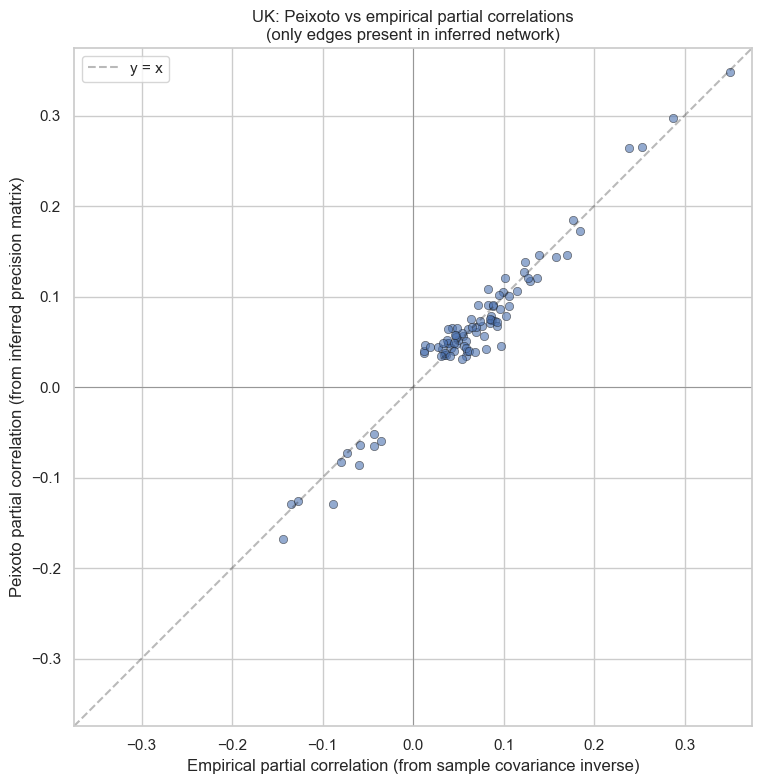

In [21]:
# Scatter plot: Peixoto partial correlations vs empirical partial correlations
fig, ax = plt.subplots(figsize=(8, 8))

peixoto_vals = []
empirical_vals = []
labels = []
for i in range(N):
    for j in range(i+1, N):
        if (i, j) in inferred_edges:
            peixoto_vals.append(pc_inferred[i, j])
            empirical_vals.append(pc_empirical[i, j])
            labels.append(f"{BELIEF_DIMS[i][:15]}–{BELIEF_DIMS[j][:15]}")

ax.scatter(empirical_vals, peixoto_vals, alpha=0.6, edgecolors="k", linewidths=0.5)
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)

lim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]),
          abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1]))
ax.plot([-lim, lim], [-lim, lim], "k--", alpha=0.3, label="y = x")
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.set_xlabel("Empirical partial correlation (from sample covariance inverse)")
ax.set_ylabel("Peixoto partial correlation (from inferred precision matrix)")
ax.set_title("UK: Peixoto vs empirical partial correlations\n(only edges present in inferred network)")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

# Analyze the inferred networks

In [28]:
# Read the inferred network from Peixoto's code (from the .graphml file)
networks_dir = "../output/networks"
network_paths = [os.path.join(networks_dir, f) for f in os.listdir(networks_dir) if f.endswith(".graphml")]
networks = {}

for path in network_paths:
    country_code = os.path.splitext(os.path.basename(path))[0]
    G = nx.read_graphml(path)
    networks[country_code] = G
    print(f"Loaded network for {country_code}: {len(G.nodes)} nodes, {len(G.edges)} edges")

# Read the belief node attribute from the graphml file and add it to the networkx graph
for country_code, G in networks.items():
    for node in G.nodes:
        belief_name = G.nodes[node].get("belief", None)
        if belief_name is not None:
            G.nodes[node]["belief"] = belief_name

Loaded network for IT: 20 nodes, 108 edges
Loaded network for CH: 20 nodes, 92 edges
Loaded network for SE: 20 nodes, 97 edges
Loaded network for HU: 20 nodes, 97 edges
Loaded network for PT: 20 nodes, 89 edges
Loaded network for FR: 20 nodes, 98 edges
Loaded network for PL: 20 nodes, 90 edges
Loaded network for GB: 20 nodes, 92 edges
Loaded network for CZ: 20 nodes, 112 edges
Loaded network for IS: 20 nodes, 94 edges
Loaded network for AT: 20 nodes, 100 edges
Loaded network for EE: 20 nodes, 89 edges
Loaded network for DE: 20 nodes, 114 edges
Loaded network for NL: 20 nodes, 90 edges
Loaded network for SI: 20 nodes, 92 edges
Loaded network for IE: 20 nodes, 113 edges
Loaded network for LT: 20 nodes, 80 edges
Loaded network for IL: 20 nodes, 98 edges
Loaded network for RU: 20 nodes, 97 edges
Loaded network for BE: 20 nodes, 110 edges
Loaded network for FI: 20 nodes, 100 edges
Loaded network for ES: 20 nodes, 89 edges
Loaded network for NO: 20 nodes, 99 edges


/var/folders/0x/hg03bl5s343fwktw7d6_x3hm0000gn/T/ipykernel_82780/1865838845.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


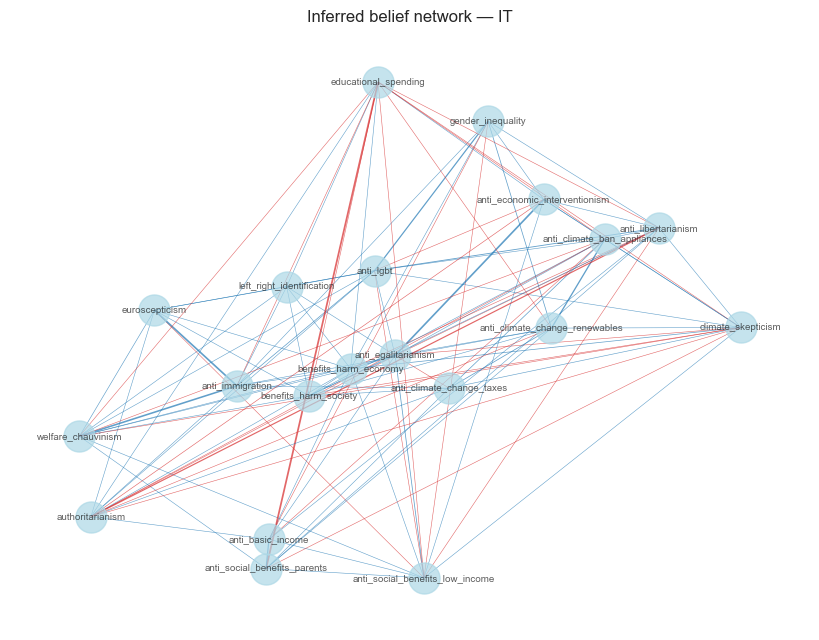

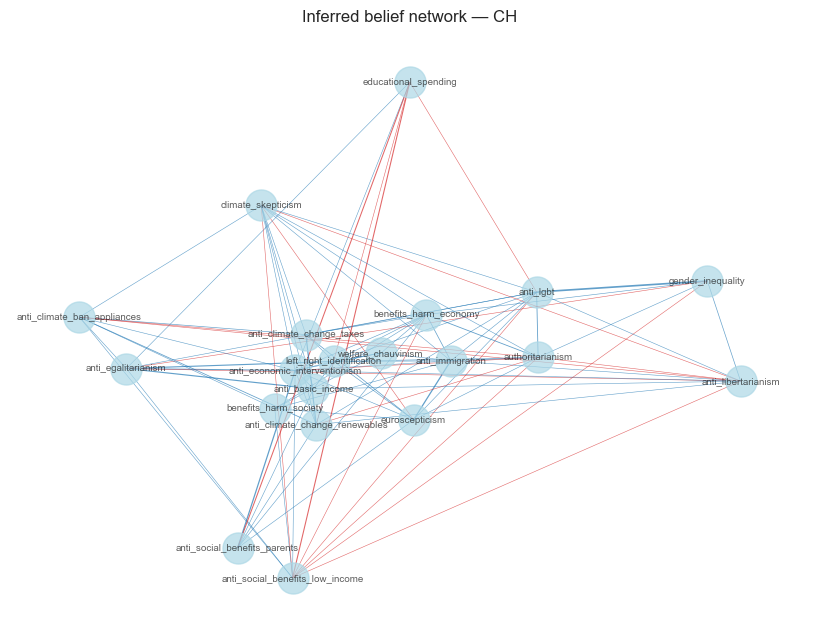

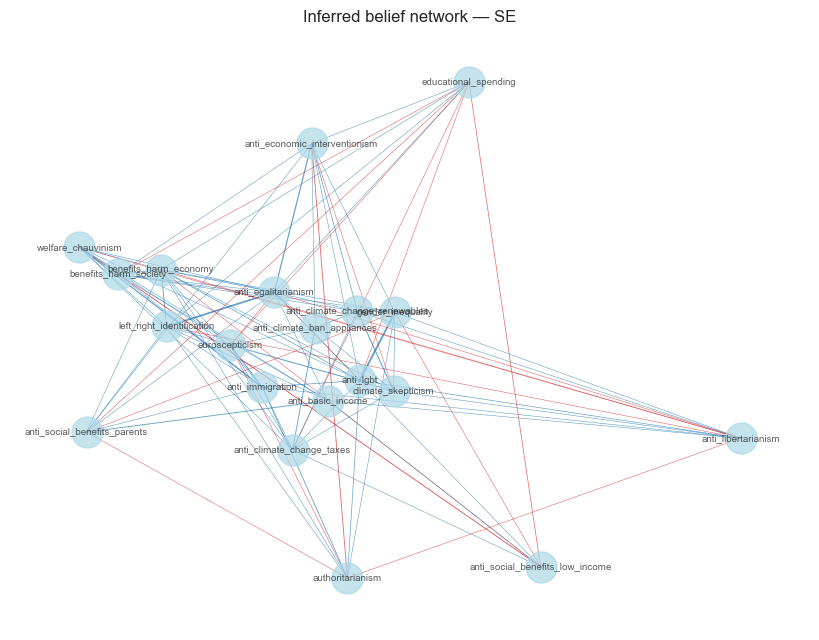

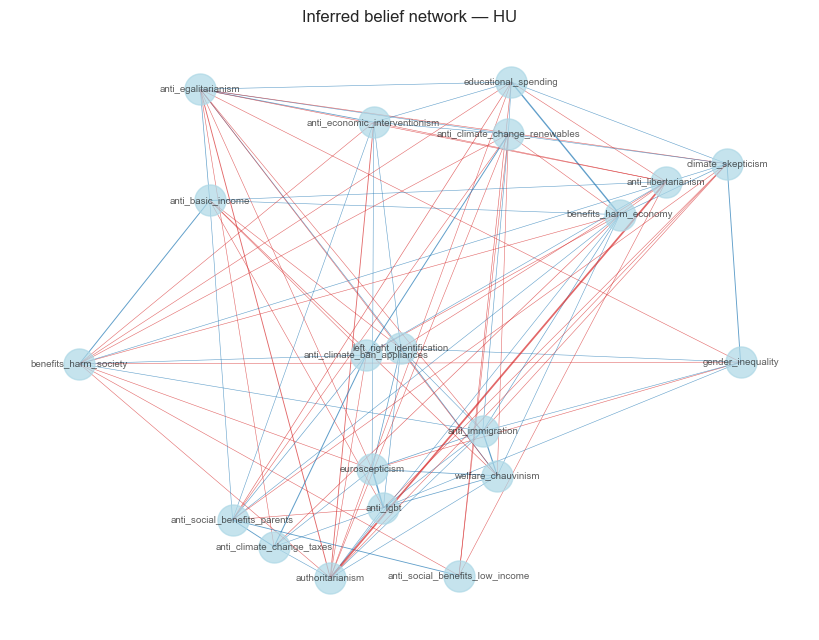

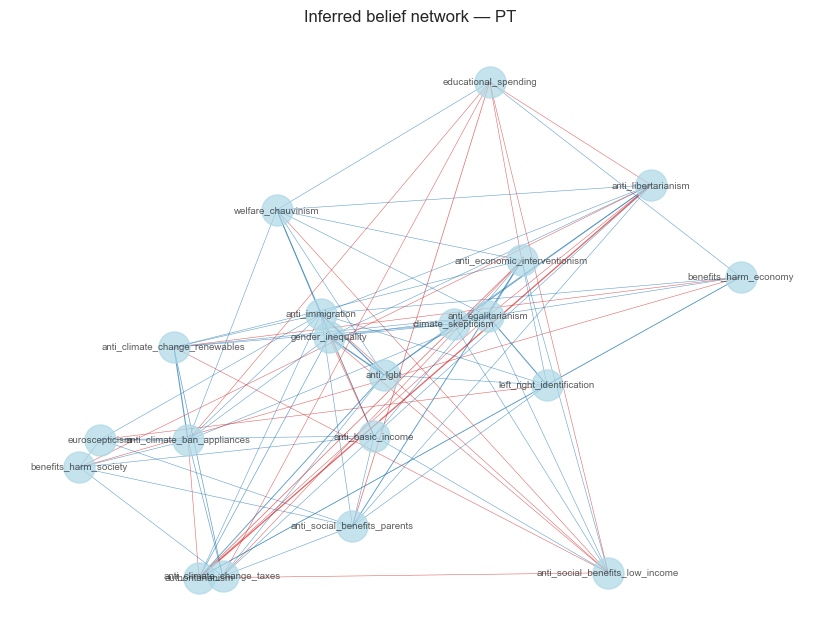

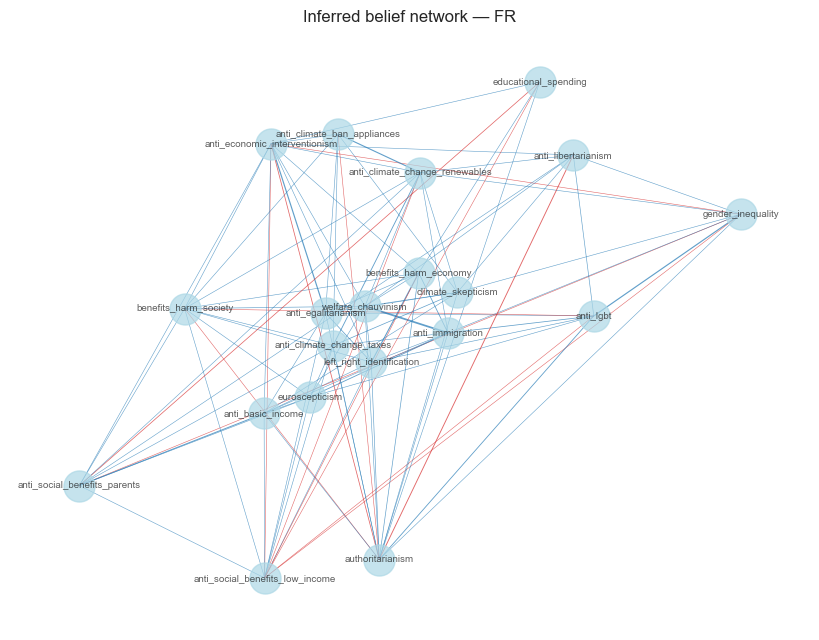

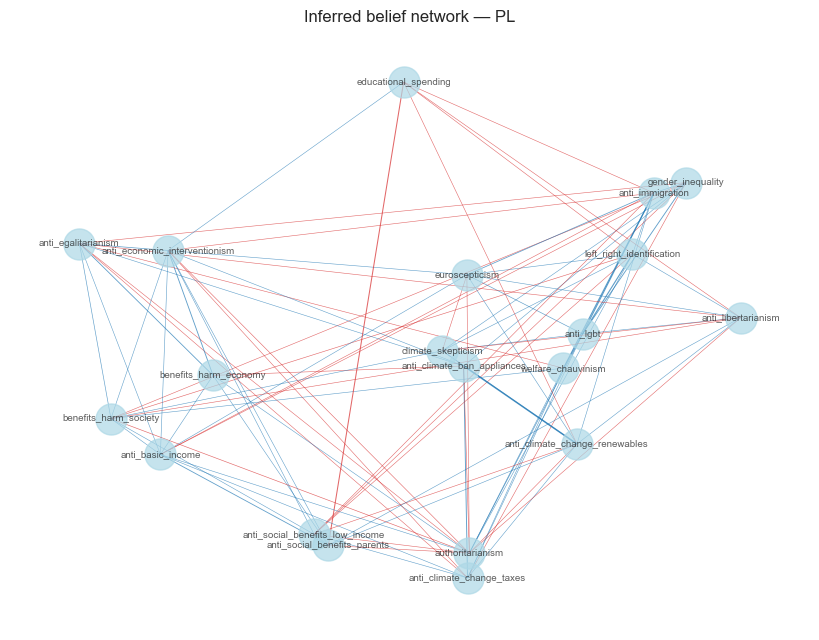

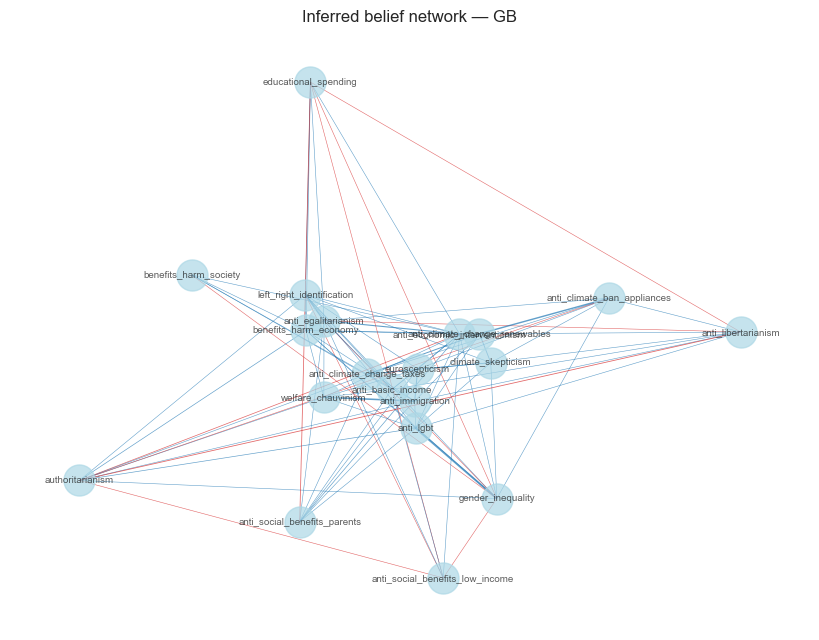

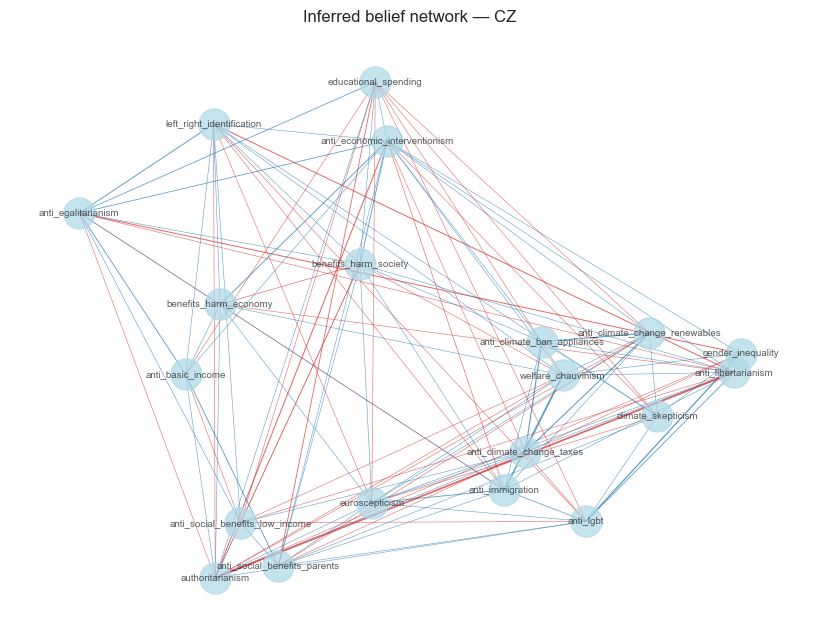

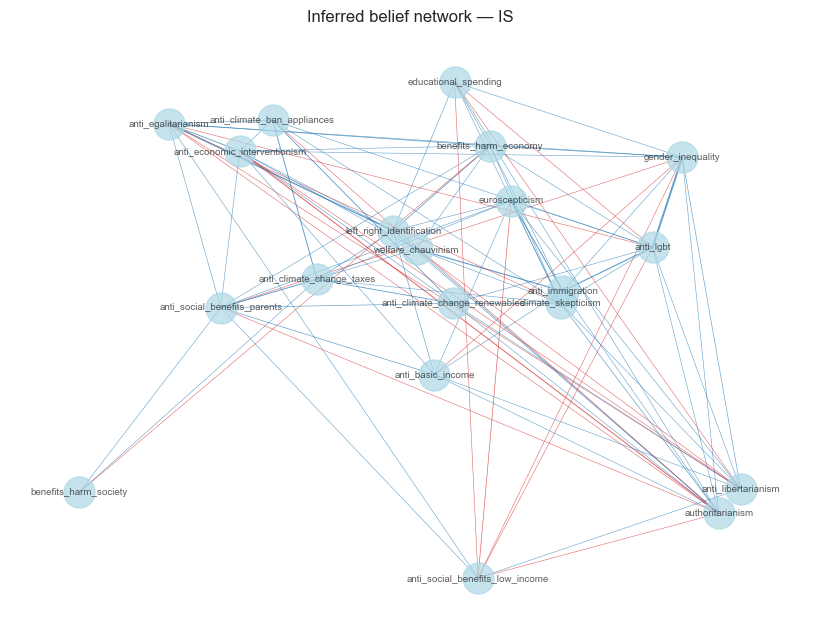

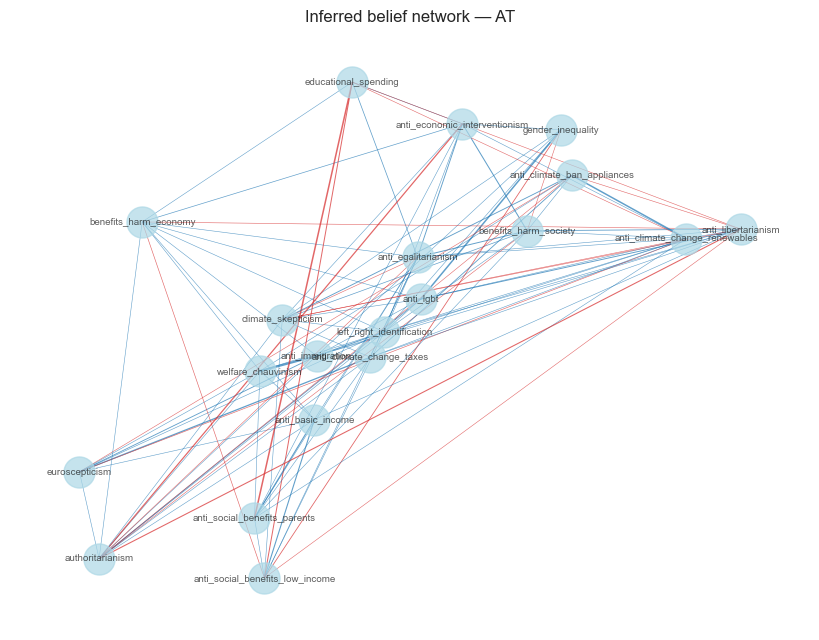

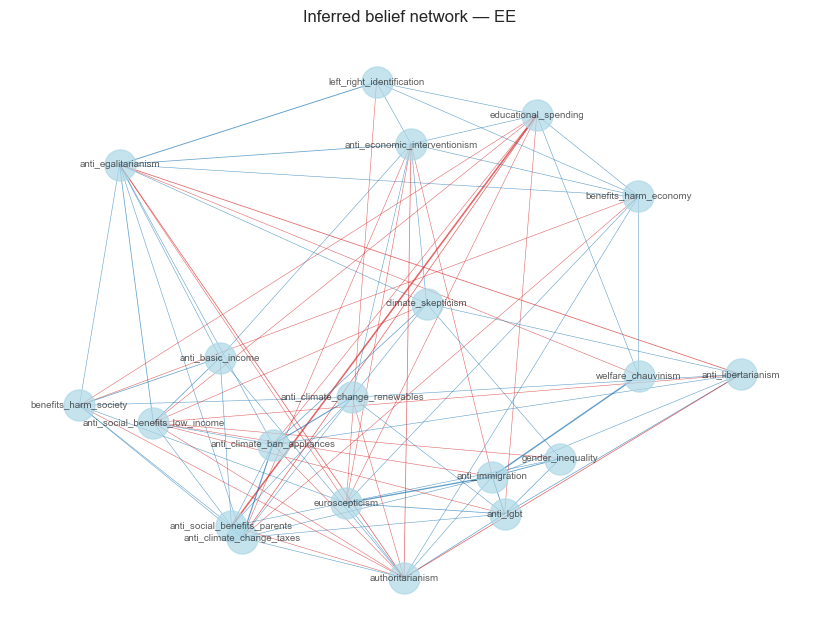

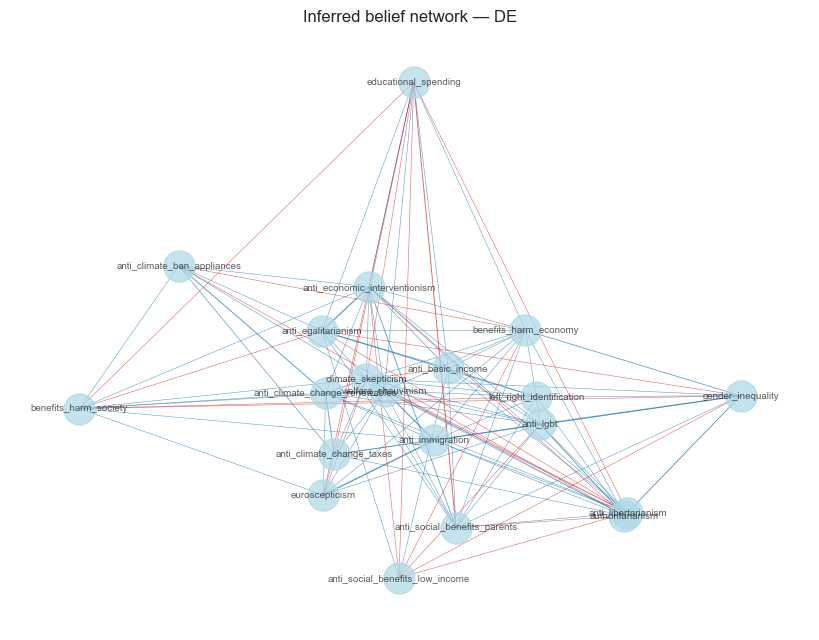

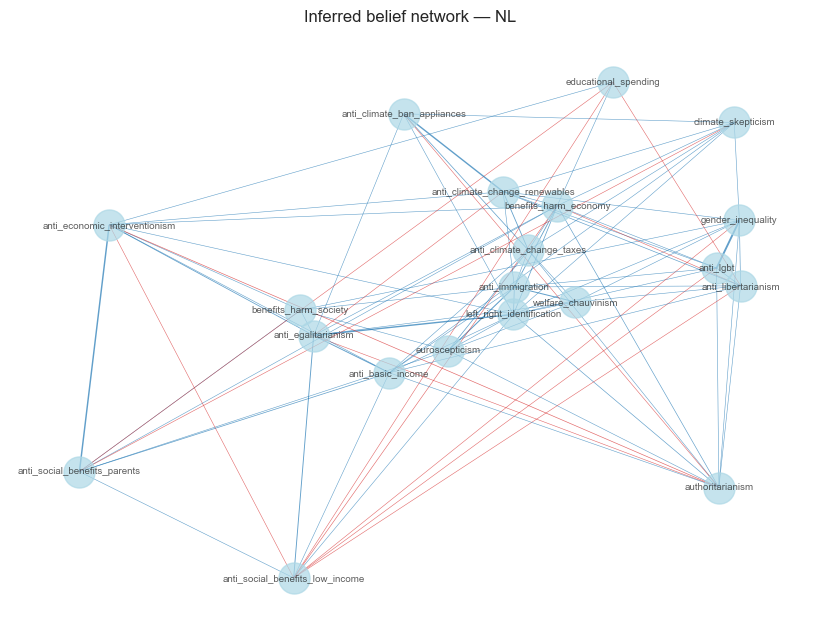

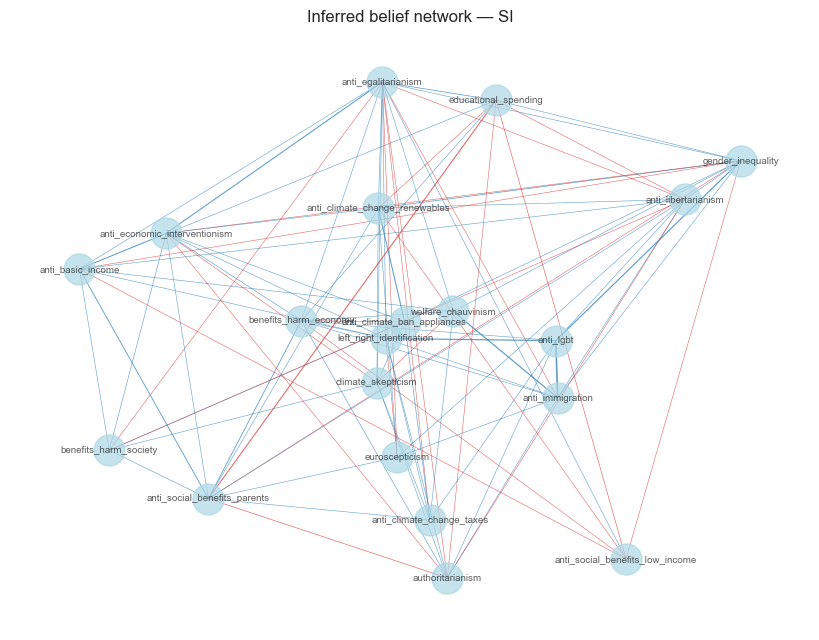

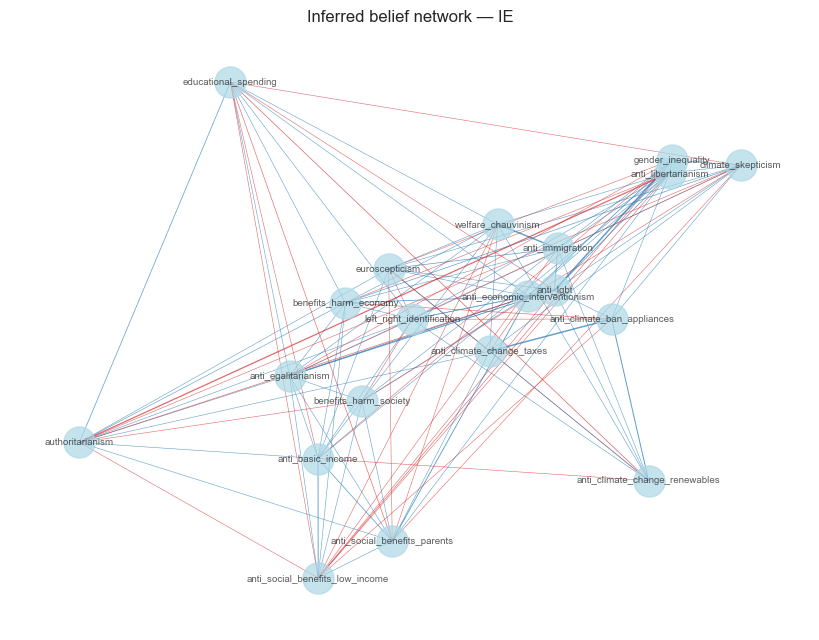

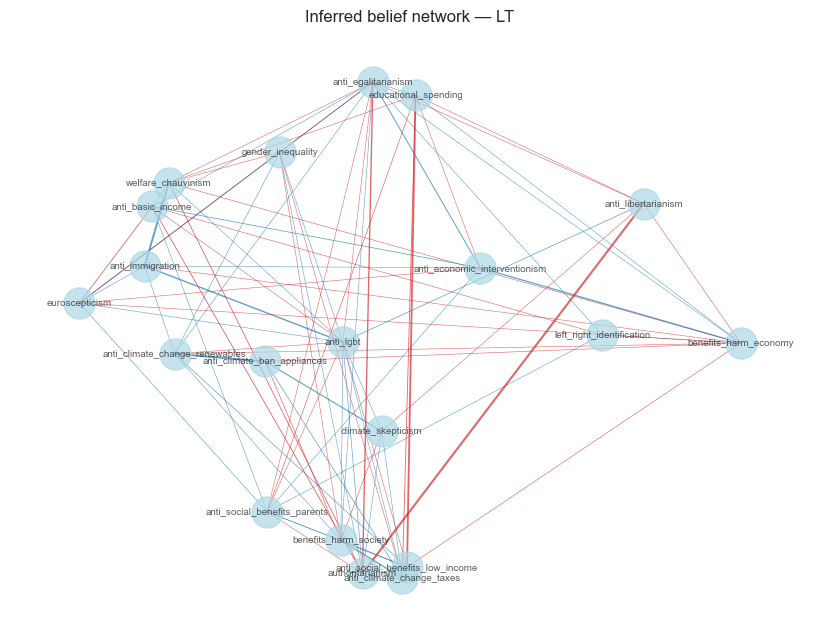

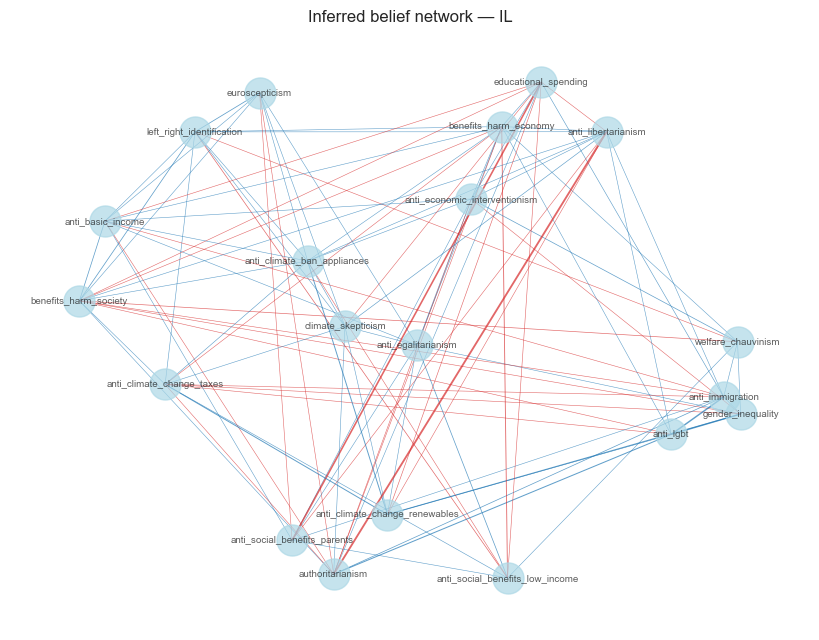

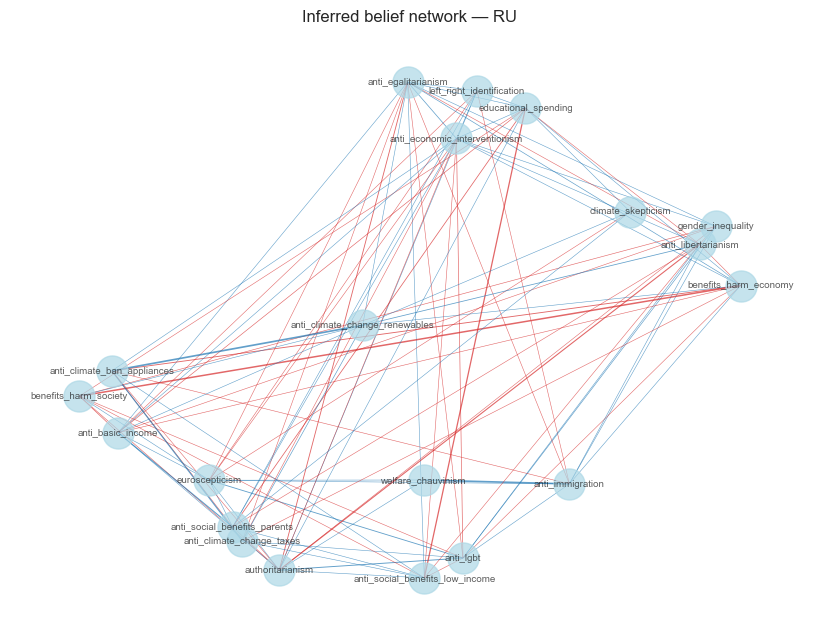

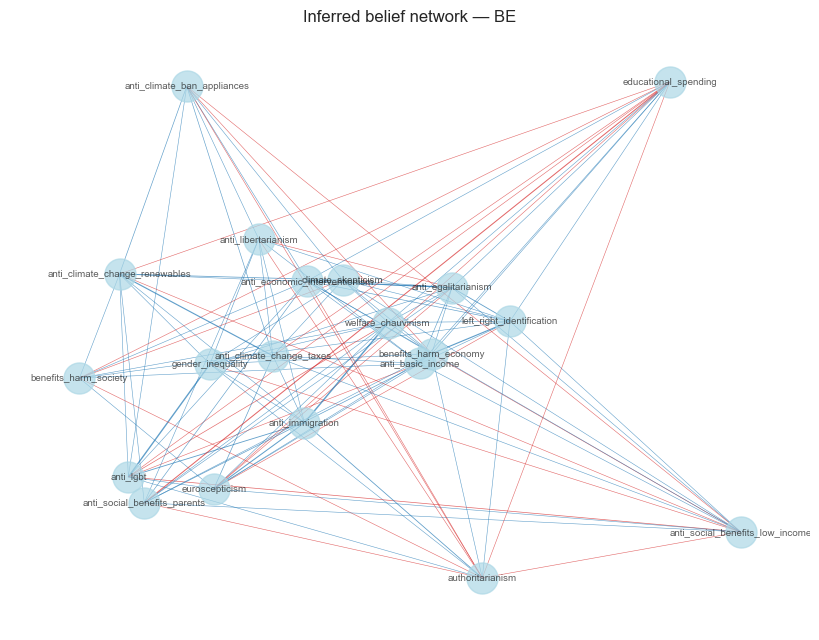

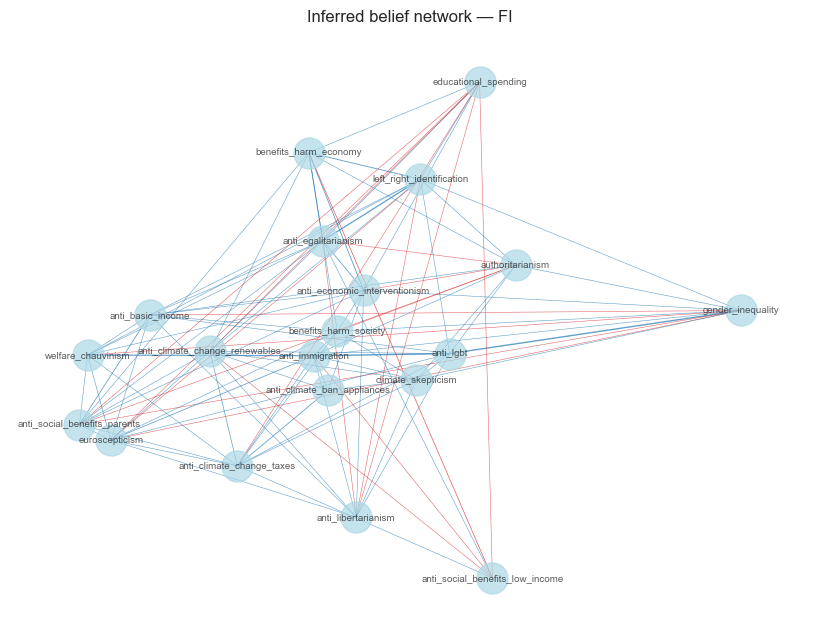

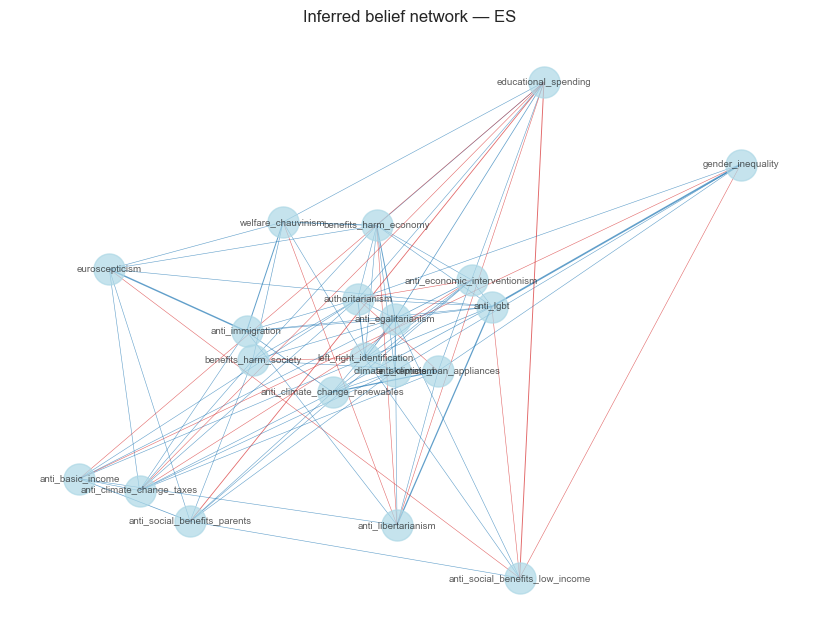

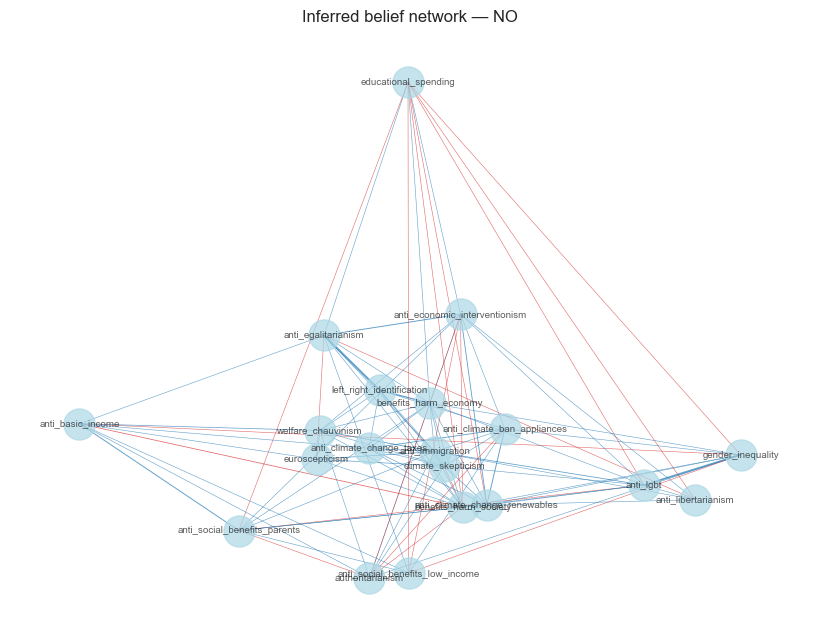

In [29]:
# visualize the networks for each country
for country_code, G in networks.items():
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    edge_colors = ['#1f77b4' if G[u][v]['weight'] > 0 else '#d62728' for u, v in G.edges()]
    edge_widths = [np.clip(abs(G[u][v]['weight']) * 4.0, 0.4, 4.0) for u, v in G.edges()]
    
    labels = {node: G.nodes[node].get("belief", node) for node in G.nodes()}
    
    nx.draw(G, pos, labels=labels, with_labels=True, node_color='lightblue', 
            edge_color=edge_colors, width=edge_widths, alpha=0.7,
            font_size=7, node_size=500)
    
    plt.title(f"Inferred belief network — {country_code.upper()}")
    plt.tight_layout()
    plt.show()